In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [12]:
# 1. Generating the Dataset
# Creating a simple 2D dataset with 300 points and 4 underlying clusters.

In [14]:
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

In [16]:
X,y

(array([[ 8.36856841e-01,  2.13635938e+00],
        [-1.41365810e+00,  7.40962324e+00],
        [ 1.15521298e+00,  5.09961887e+00],
        [-1.01861632e+00,  7.81491465e+00],
        [ 1.27135141e+00,  1.89254207e+00],
        [ 3.43761754e+00,  2.61654166e-01],
        [-1.80822253e+00,  1.59701749e+00],
        [ 1.41372442e+00,  4.38117707e+00],
        [-2.04932168e-01,  8.43209665e+00],
        [-7.11099611e-01,  8.66043846e+00],
        [-1.71237268e+00,  2.77780226e+00],
        [-2.67000792e+00,  8.35389140e+00],
        [ 1.24258802e+00,  4.50399192e+00],
        [-2.22783649e+00,  6.89479938e+00],
        [ 1.45513831e+00, -2.91989981e-02],
        [ 4.53791789e-01,  3.95647753e+00],
        [ 1.06923853e+00,  4.53068484e+00],
        [ 2.56936589e+00,  5.07048304e-01],
        [-1.06690610e+00,  3.13165795e+00],
        [-1.07859101e+00,  2.20451529e+00],
        [ 2.71506328e+00,  1.29082190e+00],
        [ 1.77710994e+00,  1.18655254e+00],
        [ 7.34363910e-01,  5.037

In [18]:
# 2. The Elbow Method 
# Calculating the Within-Cluster Sum of Squares (WCSS) or 'inertia' for 1 to 10 clusters.
wcss = []
for i in range(1, 11):
    # n_init=10 means the algorithm runs 10 times internally to find the best initial centroids
    kmeans = KMeans(n_clusters=i, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_) 


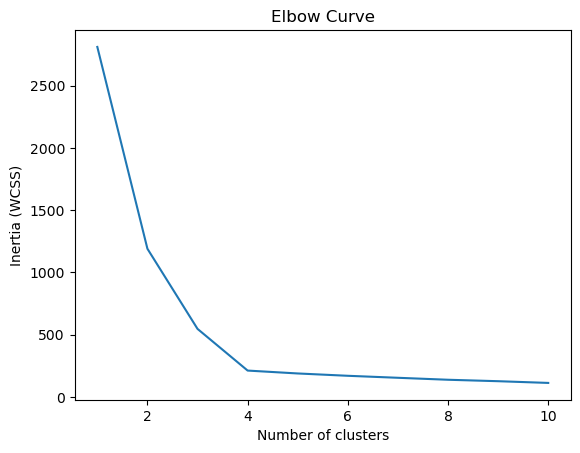

In [20]:
# Plotting the Elbow Curve to find the optimal 'K'
plt.plot(range(1, 11), wcss)
plt.title('Elbow Curve')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia (WCSS)')
plt.show()

In [22]:
# 3. Final Model Training
# Based on the elbow curve, 4 is the ideal number of clusters.
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
# fit_predict assigns every data point to a cluster (0, 1, 2, or 3)
y_kmeans = kmeans.fit_predict(X)

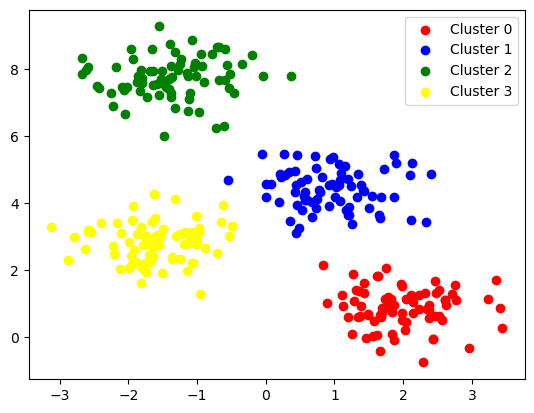

In [24]:
# 4. Visualizing the Results
# Plotting the data points and assigning colors based on their assigned cluster.
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], c='red', label='Cluster 0')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], c='blue', label='Cluster 1')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], c='green', label='Cluster 2')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], c='yellow', label='Cluster 3')
plt.legend()
plt.show()

## Detailed Explanation:
Generating Data: The code starts by generating a synthetic dataset containing 300 data points across two input features (columns) to make it easy to visualize in a 2D space.

### The Elbow Method Loop:
An empty list named wcss is created to store the "inertia" (the sum of squared distances from each point to its centroid)
A loop runs 10 times, creating a new K-Means model each time for 1 to 10 clusters.
The n_init=10 parameter ensures the algorithm tries 10 different random centroid initializations internally and picks the best one.
The calculated inertia is then appended to the list and plotted on a graph.


### Training and Prediction: 
After identifying that 4 is the optimal number of clusters from the elbow graph, the fit_predict method is called.
This method learns from the input data (X) and assigns each data point to a specific cluster (0, 1, 2, or 3), storing the result in the y_kmeans variable

### Visualization: Finally,
the code plots each data point on a scatter graph, applying a red, blue, green, or yellow color depending on which of the four clusters the point was assigned to